In [21]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [22]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
df.shape

(7043, 21)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [27]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [28]:
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"Процент ушедших клиентов соствляет {churn_rate:.2f}%")

Процент ушедших клиентов соствляет 26.54%


In [29]:
churn_month = {}
for x in range(1,73):
    churn_month[x]=len(df[(df['Churn']=='Yes') & (df['tenure']<=x)])

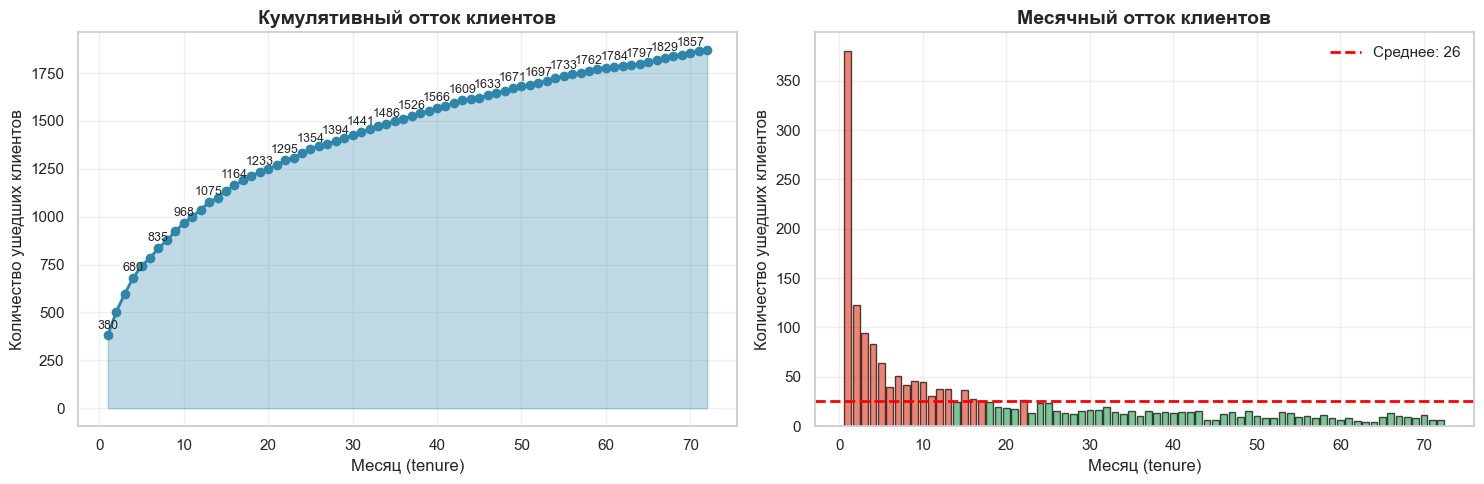

 СТАТИСТИКА ОТТОКА КЛИЕНТОВ
Всего ушло клиентов за 72 месяцев: 1869
Средний месячный отток: 26.0 клиентов
Максимальный отток в месяц: 380.0 (месяц 1)
Минимальный отток в месяц: 4.0 (месяц 63)

 ОТТОК ПО ПЕРИОДАМ:
Первые 3 месяца: 597 клиентов (31.9%)
Первые 6 месяцев: 784 клиентов (41.9%)
Первые 12 месяцев: 1037 клиентов (55.5%)


In [30]:
sns.set_context("notebook")

churn_data = {
    'month': churn_month.keys(),
    'cumulative_churn':churn_month.values()
}
df_churn = pd.DataFrame(churn_data)

df_churn['monthly_churn'] = df_churn['cumulative_churn'].diff().fillna(df_churn['cumulative_churn'].iloc[0])

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(df_churn['month'], df_churn['cumulative_churn'], 
         marker='o', linewidth=2, markersize=6, color='#2E86AB')
ax1.fill_between(df_churn['month'], df_churn['cumulative_churn'], 
                 alpha=0.3, color='#2E86AB')
ax1.set_title('Кумулятивный отток клиентов', fontsize=14, fontweight='bold')
ax1.set_xlabel('Месяц (tenure)', fontsize=12)
ax1.set_ylabel('Количество ушедших клиентов', fontsize=12)
ax1.grid(True, alpha=0.3)

for i, (month, churn) in enumerate(zip(df_churn['month'], df_churn['cumulative_churn'])):
    if i % 3 == 0:  # Показываем каждую 3-ю точку для читаемости
        ax1.annotate(str(churn), (month, churn), textcoords="offset points", 
                    xytext=(0,5), ha='center', fontsize=9)
        
colors = ['#E94F37' if x > df_churn['monthly_churn'].mean() 
          else '#44AF69' for x in df_churn['monthly_churn']]

ax2.bar(df_churn['month'], df_churn['monthly_churn'], color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(y=df_churn['monthly_churn'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Среднее: {df_churn["monthly_churn"].mean():.0f}')
ax2.set_title('Месячный отток клиентов', fontsize=14, fontweight='bold')
ax2.set_xlabel('Месяц (tenure)', fontsize=12)
ax2.set_ylabel('Количество ушедших клиентов', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/Customer Churn Analysis by Tenure.png') 

plt.show()
print("="*60)
print(" СТАТИСТИКА ОТТОКА КЛИЕНТОВ")
print("="*60)
print(f"Всего ушло клиентов за 72 месяцев: {df_churn['cumulative_churn'].iloc[-1]}")
print(f"Средний месячный отток: {df_churn['monthly_churn'].mean():.1f} клиентов")
print(f"Максимальный отток в месяц: {df_churn['monthly_churn'].max()} (месяц {df_churn['monthly_churn'].idxmax()+1})")
print(f"Минимальный отток в месяц: {df_churn['monthly_churn'].min()} (месяц {df_churn['monthly_churn'].idxmin()+1})")
print("="*60)

print("\n ОТТОК ПО ПЕРИОДАМ:")
print(f"Первые 3 месяца: {df_churn['cumulative_churn'].iloc[2]} клиентов ({df_churn['cumulative_churn'].iloc[2]/df_churn['cumulative_churn'].iloc[-1]*100:.1f}%)")
print(f"Первые 6 месяцев: {df_churn['cumulative_churn'].iloc[5]} клиентов ({df_churn['cumulative_churn'].iloc[5]/df_churn['cumulative_churn'].iloc[-1]*100:.1f}%)")
print(f"Первые 12 месяцев: {df_churn['cumulative_churn'].iloc[11]} клиентов ({df_churn['cumulative_churn'].iloc[11]/df_churn['cumulative_churn'].iloc[-1]*100:.1f}%)")

Клиенты с низким ежемесячным платежом (~$20) демонстрируют значительно лучшую лояльность и реже уходят, тогда как сегмент с высоким чеком ($80-100) показывает максимальный отток. Это указывает на то, что дорогие тарифы не оправдывают ожидания клиентов или предлагают недостаточную ценность за свою стоимость. В целях удержания high-value клиентов рекомендуется: провести аудит премиум-тарифов и их конкурентоспособности, запустить персональные retention-кампании для клиентов с MonthlyCharges > $80, рассмотреть возможность добавления дополнительной ценности в дорогие тарифы или предложить персональные скидки лояльным клиентам из группы риска.


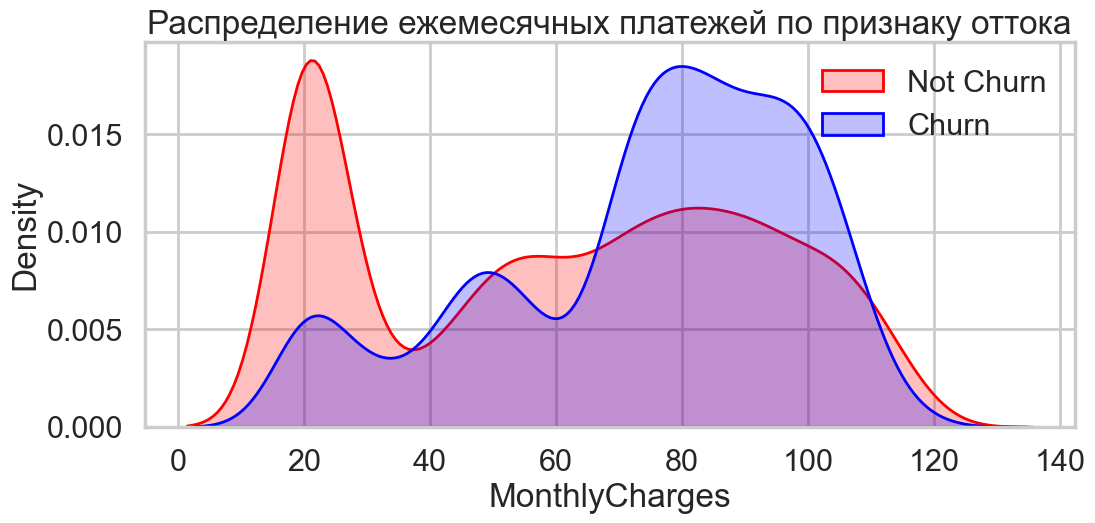

In [31]:
sns.set_context("poster")
ax = sns.kdeplot(data = df.MonthlyCharges[df['Churn']=='No'],color = 'Red',fill = True)
ax = sns.kdeplot(data = df.MonthlyCharges[df['Churn']=='Yes'],color = 'Blue',fill = True)
ax.legend(['Not Churn','Churn'],loc = 'upper right')
ax.set_title('Распределение ежемесячных платежей по признаку оттока')
plt.savefig('../images/Distribution of monthly charges by churn.png')
print("Клиенты с низким ежемесячным платежом (~$20) демонстрируют значительно лучшую лояльность и реже уходят, тогда как сегмент с высоким чеком ($80-100) показывает максимальный отток. Это указывает на то, что дорогие тарифы не оправдывают ожидания клиентов или предлагают недостаточную ценность за свою стоимость. В целях удержания high-value клиентов рекомендуется: провести аудит премиум-тарифов и их конкурентоспособности, запустить персональные retention-кампании для клиентов с MonthlyCharges > $80, рассмотреть возможность добавления дополнительной ценности в дорогие тарифы или предложить персональные скидки лояльным клиентам из группы риска.")

In [32]:
contract_churn ={}
for contract_type in df['Contract'].unique():
    contract_mask = df['Contract'] == contract_type
    contract_df = df[contract_mask]
    
    total = len(contract_df)
    churned = len(contract_df[contract_df['Churn'] == 'Yes'])
    
    contract_churn[contract_type] = round(churned / total * 100, 2)
    print(f"Ушедших при контракте {contract_type}: {contract_churn[contract_type]}%")

Ушедших при контракте Month-to-month: 42.71%
Ушедших при контракте One year: 11.27%
Ушедших при контракте Two year: 2.83%


$D={(c_{i},y_{i},....,k_{i})}_{i=0}^{n}~-~Набор~данных ,c_{i}\in{('Month-to-month','One~year','Two~year')}-тип~контракта$
$y_{i} \in {('Yes','No')}-Метка~оттока \newline$
$contract\_churn[contract\_type] =\frac{\sum_{i=0}^{n}~I(c_{i}=contract\_type ~\land~ y_{i}='Yes')}{\sum_{i=0}^{n}I(c_{i}=contract\_type)}\times100\%$

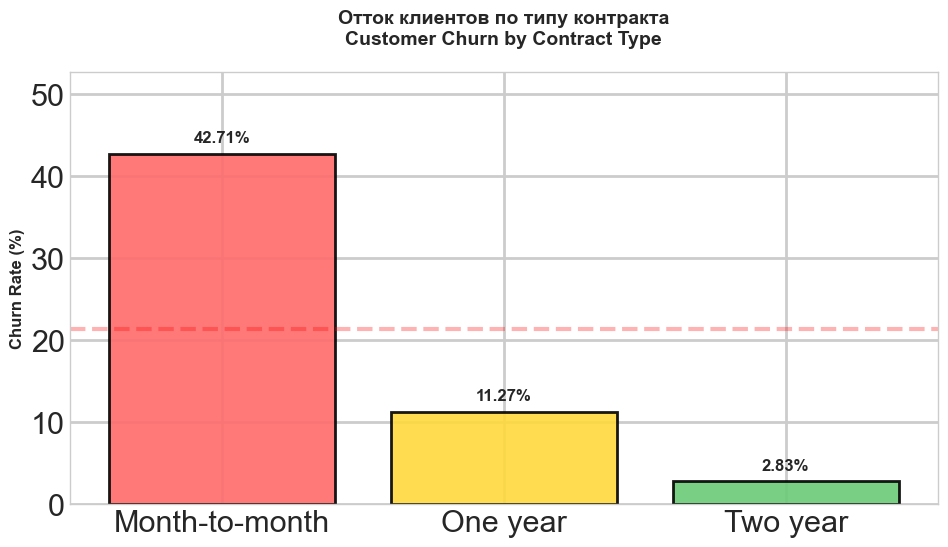

Годовые контракты показывают в 4 раза лучшее удержание клиентов (churn 11.27% vs 42.71% для Month-to-Month). Для увеличения LTV рекомендуется запустить таргетированную маркетинговую кампанию по переводу клиентов с месячных на годовые контракты с incentivaми (скидка 10-15% или бонусные месяцы


In [33]:
contract_data = {
    "contract": contract_churn.keys(),
    "churn":contract_churn.values()
}

df_contract = pd.DataFrame(contract_data)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))


churn_rates=df_contract['churn']
contracts = df_contract['contract']
colors = ['#ff6b6b', '#ffd93d', '#6bcb77']#Крсасный , желтый , зелегый 


bars = ax.bar(contracts, churn_rates, color=colors, edgecolor='black', alpha=0.9)

# Добавление значений на столбцы
for bar, rate in zip(bars, churn_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{rate}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Оформление
ax.set_ylabel('Churn Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Отток клиентов по типу контракта\nCustomer Churn by Contract Type', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, max(churn_rates) + 10)
ax.axhline(y=churn_rates[0]*0.5, color='red', linestyle='--', alpha=0.3, label='50% от Month-to-month')
plt.savefig('../images/Customer Churn by Contract Type.png') 
plt.tight_layout()
plt.show()
print("Годовые контракты показывают в 4 раза лучшее удержание клиентов (churn 11.27% vs 42.71% для Month-to-Month). Для увеличения LTV рекомендуется запустить таргетированную маркетинговую кампанию по переводу клиентов с месячных на годовые контракты с incentivaми (скидка 10-15% или бонусные месяцы")

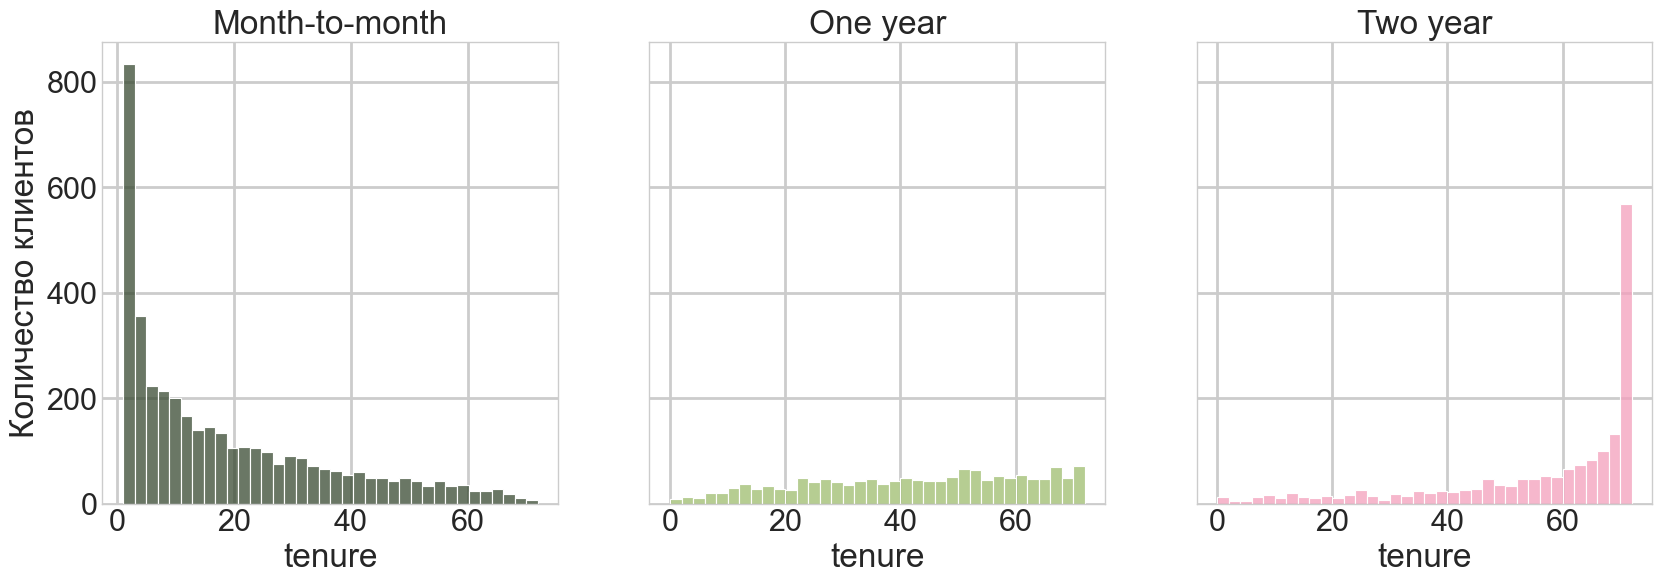

In [34]:
fig , (ax1,ax2,ax3) = plt.subplots(nrows = 1 , ncols = 3 , sharey = 1 , figsize = (20,6))

ax = sns.histplot(df[df['Contract']=='Month-to-month']['tenure'],bins = int(180/5),color = '#384931',ax=ax1)

ax.set_title('Month-to-month')
ax.set_ylabel('Количество клиентов')
ax.set_label('Tenure(months)')

ax = sns.histplot(df[df['Contract']=='One year']['tenure'],bins = int(180/5),color = '#9ebd6e',ax = ax2 )

ax.set_title('One year')
ax.set_label('Tenure(months)')

ax = sns.histplot(df[df['Contract']=='Two year']['tenure'],bins = int(180/5),color = '#f49fbc',ax = ax3 )
ax.set_title('Two year')
ax.set_label('Tenure(months)')

plt.savefig('../images/Customer Churn Analysis by Tenure.png') 


In [35]:
labels = df['PaymentMethod'].unique()
values = df['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Расприделение методов оплаты</b>")
fig.show()

In [36]:
fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Распределение способов оплаты в зависимости от оттока Churn</b>",barmode='relative')
fig.update_layout(width=700, height=500, bargap=0.1)
plt.savefig('../images/Customer Payment Method distribution w.r.t. Churn.png') 
fig.show()
print("Автоматические методы оплаты демонстрируют значительно лучшее удержание клиентов. Клиенты использующие Electronic check и Mailed check (ручная оплата) преобладают среди ушедших, тогда как клиенты с Bank transfer и Credit card (automatic) показывают высокую лояльность. В целях снижения оттока имеет смысл запустить кампанию по переводу клиентов на автоматические платежи, предложив инсентивы (скидку $3-5/мес или бонусные дни за подключение auto-pay).")


Автоматические методы оплаты демонстрируют значительно лучшее удержание клиентов. Клиенты использующие Electronic check и Mailed check (ручная оплата) преобладают среди ушедших, тогда как клиенты с Bank transfer и Credit card (automatic) показывают высокую лояльность. В целях снижения оттока имеет смысл запустить кампанию по переводу клиентов на автоматические платежи, предложив инсентивы (скидку $3-5/мес или бонусные дни за подключение auto-pay).


<Figure size 1200x500 with 0 Axes>

In [37]:
labels = df['gender'].unique()
values = df['gender'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Расриделение по полу </b>")
fig.show()

In [38]:
values = df[df['Churn']=='Yes']['gender'].value_counts()
labels=values.index

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Распределение оттока клиентов по полу</b>")
fig.show()
print("Вывод пол не влияет на отток")

Вывод пол не влияет на отток


<h2>Бизнес рекомендации</h2>
<h4>1.Тип контракта — главный драйвер оттока</h4>
Годовые контракты показывают лучшее удержание клиентов. Клиенты на Month-to-Month контрактах уходят в 4 раза чаще (churn rate 42.71% vs 11.27% для годовых контрактов). В целях увеличения LTV имеет смысл запустить маркетинговую акцию с целью перевода клиентов с Month-to-Month на годовые контракты с инсентивами (скидка 10-15% или акция "12 месяцев по цене 11").

<h4>2.Метод оплаты критически влияет на удержание</h4>
Автоматические методы оплаты демонстрируют значительно лучшее удержание клиентов. Клиенты, использующие Electronic check и Mailed check (ручная оплата), преобладают среди ушедших, тогда как клиенты с Bank transfer и Credit card (automatic) показывают высокую лояльность. В целях снижения оттока имеет смысл запустить кампанию по переводу клиентов на автоматические платежи, предложив инсентивы (скидку $3-5/мес или бонусные дни за подключение auto-pay).

<h4>3.Высокий чек коррелирует с оттоком</h4>
Клиенты с низким ежемесячным платежом (~\$20) демонстрируют значительно лучшую лояльность и реже уходят, тогда как сегмент с высоким чеком (\$80-100) показывает максимальный отток. Это указывает на то, что дорогие тарифы не оправдывают ожидания клиентов или предлагают недостаточную ценность за свою стоимость. В целях удержания high-value клиентов рекомендуется:
<ul>
     <li>Провести аудит премиум-тарифов и их конкурентоспособности </li>
    <li>Запустить персональные retention-кампании для клиентов с MonthlyCharges > $80</li>
    <li>Рассмотреть возможность добавления дополнительной ценности в дорогие тарифы</li>
</ul>
<h4>4.Критический период — первые 3 месяца</h4>
31.9% клиентов уходят в первые 3 месяца, 55.5% — в первый год. Пик оттока приходится на 1-й месяц (380 клиентов). Рекомендуется:
<ul>
    <li>Внедрить усиленную программу онбординга для новых клиентов</li>
    <li>Назначить персонального менеджера на первые 90 дней</li>
   <li>Отправлять приветственные письма/звонки в первую неделю</li>
    <li>Выяснить причину массового ухода в 1-й месяц</li>
</ul>
